# 02. Entrenamiento completo del modelo - ConcertDemandAI

## Introducción a los modelos de entrenamiento

En este notebook se entrenan y comparan distintos modelos de clasificación para predecir la demanda esperada de conciertos en tres categorías: `baja`, `media` y `alta`. El objetivo no es utilizar un solo algoritmo desde el inicio, sino realizar una comparación experimental que permita identificar qué modelo se adapta mejor al comportamiento del dataset.

Para este proyecto se utilizan variables disponibles antes del evento, como artista, género musical, ciudad, país, tipo de recinto, capacidad, fecha del evento, precio del boleto, presupuesto de marketing, popularidad del artista, historial previo de asistencia e interés de preventa. No se utilizan variables como `occupancy_pct` ni `tickets_sold` como entradas del modelo, ya que representan información posterior al evento y podrían generar fuga de información.

Los modelos seleccionados son:

- **Logistic Regression**: se utiliza como modelo base lineal. Permite tener una primera referencia del desempeño y comprobar si el problema puede resolverse con relaciones simples entre las variables.

- **Decision Tree**: se incluye por ser un modelo interpretable, basado en reglas de decisión. Es útil para observar cómo ciertas combinaciones de variables pueden llevar a una clase de demanda específica.

- **Random Forest**: se utiliza porque combina múltiples árboles de decisión, lo que mejora la estabilidad del modelo y reduce el riesgo de depender de un solo árbol. Es adecuado para datasets con variables numéricas y categóricas.

- **Extra Trees**: se incluye como una variante de ensamble basada en árboles con mayor aleatoriedad. Permite comparar si una construcción más diversa de árboles mejora la generalización del modelo.

- **Gradient Boosting**: se utiliza porque construye modelos de forma secuencial, corrigiendo errores de modelos anteriores. Es útil para capturar patrones más complejos en la predicción de demanda.

Además, se aplica **RandomizedSearchCV** para optimizar los hiperparámetros de los modelos más fuertes. Esto permite probar distintas configuraciones y seleccionar la que ofrece mejor desempeño.

La evaluación no se basa únicamente en `accuracy`, sino también en métricas como `precision`, `recall`, `f1-score`, `f1_macro` y matriz de confusión. Esto es importante porque el objetivo es que el modelo tenga un desempeño equilibrado en las tres clases de demanda, especialmente en la clase `media`, que suele ser la más difícil de clasificar por encontrarse entre los casos de baja y alta demanda.

**ConcertDemandAI flujo**.

Incluye:

1. Carga y validación del dataset.
2. Preparación de variables.
3. División entrenamiento/prueba.
4. Preprocesamiento de variables categóricas y numéricas.
5. Entrenamiento de modelos base.
6. Evaluación con métricas completas:
   - Accuracy
   - Precision macro
   - Recall macro
   - F1 macro
   - F1 weighted
   - Classification report
   - Matriz de confusión
7. Optimización de modelos con `RandomizedSearchCV`.
8. Comparación de modelos base vs optimizados.
9. Selección del mejor modelo usando `f1_macro`.
10. Guardado de:
   - `model/model.pkl`
   - `model/metrics.txt`
   - `model/metrics.json`
11. Pruebas manuales de predicción.

> No se usan `occupancy_pct` ni `tickets_sold` como variables de entrada, porque representan información posterior al evento.


## 1. Configuración del entorno

Esta celda permite ejecutar el notebook en Google Colab. Si el repositorio no existe en `/content`, se clona automáticamente desde GitHub.


In [1]:
from pathlib import Path
import os

REPO_URL = "https://github.com/leonciochiunti/concert-demand-ml.git"
REPO_DIR = Path("/content/concert-demand-ml")

if Path("/content").exists():
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    %cd /content/concert-demand-ml
    !git pull origin main
else:
    print("Entorno local detectado")
    print("Carpeta actual:", Path.cwd())

print("Carpeta de trabajo:", Path.cwd())
print("Archivos disponibles:")
print(os.listdir())

Cloning into '/content/concert-demand-ml'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 44 (delta 10), reused 32 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 118.23 KiB | 515.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/concert-demand-ml
From https://github.com/leonciochiunti/concert-demand-ml
 * branch            main       -> FETCH_HEAD
Already up to date.
Carpeta de trabajo: /content/concert-demand-ml
Archivos disponibles:
['requirements.txt', 'app', 'data', 'notebooks', 'model', 'README.md', '.git', '.gitignore', 'reports']


## 2. Importación de librerías

In [2]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

## 3. Definición de rutas

In [3]:
BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "data" / "dataset.csv"
MODEL_PATH = BASE_DIR / "model" / "model.pkl"
METRICS_TXT_PATH = BASE_DIR / "model" / "metrics.txt"
METRICS_JSON_PATH = BASE_DIR / "model" / "metrics.json"

print("Dataset:", DATA_PATH)
print("Modelo:", MODEL_PATH)
print("Métricas TXT:", METRICS_TXT_PATH)
print("Métricas JSON:", METRICS_JSON_PATH)

Dataset: /content/concert-demand-ml/data/dataset.csv
Modelo: /content/concert-demand-ml/model/model.pkl
Métricas TXT: /content/concert-demand-ml/model/metrics.txt
Métricas JSON: /content/concert-demand-ml/model/metrics.json


## 4. Carga y validación del dataset

Se valida que el dataset contenga las columnas necesarias para entrenar el modelo final.

El dataset actualizado debe incluir variables históricas simuladas, como:

- `previous_attendance_rate`
- `pre_sale_interest`
- `artist_market_score`
- `is_weekend`
- `marketing_per_capacity`
- `price_per_capacity`
- `popularity_marketing`


In [4]:
FEATURES = [
    "artist",
    "genre",
    "city",
    "country",
    "venue_type",
    "capacity",
    "month",
    "event_day",
    "days_until_event",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "previous_attendance_rate",
    "pre_sale_interest",
    "artist_market_score",
    "is_weekend",
    "marketing_per_capacity",
    "price_per_capacity",
    "popularity_marketing",
]

TARGET = "demand_class"

CATEGORICAL_FEATURES = [
    "artist",
    "genre",
    "city",
    "country",
    "venue_type",
    "event_day",
]

NUMERIC_FEATURES = [
    "capacity",
    "month",
    "days_until_event",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "previous_attendance_rate",
    "pre_sale_interest",
    "artist_market_score",
    "is_weekend",
    "marketing_per_capacity",
    "price_per_capacity",
    "popularity_marketing",
]

df = pd.read_csv(DATA_PATH)

required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        "Faltan columnas en el dataset. "
        f"Columnas faltantes: {missing_columns}. "
        "Asegúrate de usar el dataset actualizado con variables históricas."
    )

print("Dataset cargado correctamente")
print("Filas y columnas:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nDistribución de clases:")
print(df[TARGET].value_counts())

print("\nValores nulos en columnas usadas:")
print(df[required_columns].isnull().sum())

display(df.head())

Dataset cargado correctamente
Filas y columnas: (1200, 22)

Columnas:
['artist', 'genre', 'city', 'country', 'venue_type', 'capacity', 'month', 'event_day', 'days_until_event', 'marketing_budget', 'ticket_price', 'artist_popularity', 'previous_attendance_rate', 'pre_sale_interest', 'artist_market_score', 'is_weekend', 'marketing_per_capacity', 'price_per_capacity', 'popularity_marketing', 'occupancy_pct', 'tickets_sold', 'demand_class']

Distribución de clases:
demand_class
media    400
baja     400
alta     400
Name: count, dtype: int64

Valores nulos en columnas usadas:
artist                      0
genre                       0
city                        0
country                     0
venue_type                  0
capacity                    0
month                       0
event_day                   0
days_until_event            0
marketing_budget            0
ticket_price                0
artist_popularity           0
previous_attendance_rate    0
pre_sale_interest           0
a

,artist,genre,city,country,venue_type,capacity,month,event_day,days_until_event,marketing_budget,...,previous_attendance_rate,pre_sale_interest,artist_market_score,is_weekend,marketing_per_capacity,price_per_capacity,popularity_marketing,occupancy_pct,tickets_sold,demand_class
0,David Guetta,electronica,Los Angeles,Estados Unidos,theater,7078,5,Thursday,2,157082,...,0.82,4197,0.95,0,22.192992,4.699350,14608626,0.64,4530,media
1,Grupo Firme,banda,Bogota,Colombia,club,1791,12,Wednesday,27,51833,...,0.78,1193,0.88,0,28.940815,0.968174,4664970,0.54,967,baja
2,The Weeknd,pop,Queretaro,Mexico,theater,8188,10,Thursday,172,227767,...,0.90,5682,0.82,0,27.817171,0.504275,21865632,0.72,5895,media
3,Peso Pluma,regional_mexicano,Queretaro,Mexico,stadium,38238,11,Friday,76,471399,...,0.58,15550,0.82,1,12.328024,0.043909,43840107,0.69,26384,media
4,Ariana Grande,pop,Guadalajara,Mexico,theater,4786,6,Wednesday,48,73054,...,0.88,2651,0.92,0,15.264104,0.662975,6940130,0.59,2824,media


## 5. Limpieza preventiva de columnas utilizadas

Se convierten las columnas categóricas a texto y se rellenan valores faltantes.  
También se limpian valores infinitos o nulos en columnas numéricas.


In [7]:
df = df.copy()

for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("unknown").astype(str)

for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].replace([np.inf, -np.inf], np.nan)
df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)

print("Limpieza preventiva completada.")
print("\nValores nulos en features:")
print(df[FEATURES].isnull().sum())

Limpieza preventiva completada.

Valores nulos en features:
artist                      0
genre                       0
city                        0
country                     0
venue_type                  0
capacity                    0
month                       0
event_day                   0
days_until_event            0
marketing_budget            0
ticket_price                0
artist_popularity           0
previous_attendance_rate    0
pre_sale_interest           0
artist_market_score         0
is_weekend                  0
marketing_per_capacity      0
price_per_capacity          0
popularity_marketing        0
dtype: int64


## 6. Preparación de variables

Se separan las variables de entrada (`X`) y la variable objetivo (`y`).

No se incluyen `occupancy_pct` ni `tickets_sold` en `FEATURES`, porque son resultados posteriores al evento.


In [8]:
X = df[FEATURES]
y = df[TARGET]

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

display(X.head())
display(y.head())

Tamaño de X: (1200, 19)
Tamaño de y: (1200,)


,artist,genre,city,country,venue_type,capacity,month,event_day,days_until_event,marketing_budget,ticket_price,artist_popularity,previous_attendance_rate,pre_sale_interest,artist_market_score,is_weekend,marketing_per_capacity,price_per_capacity,popularity_marketing
0,David Guetta,electronica,Los Angeles,Estados Unidos,theater,7078,5,Thursday,2,157082,33262,93,0.82,4197,0.95,0,22.192992,4.699350,14608626
1,Grupo Firme,banda,Bogota,Colombia,club,1791,12,Wednesday,27,51833,1734,90,0.78,1193,0.88,0,28.940815,0.968174,4664970
2,The Weeknd,pop,Queretaro,Mexico,theater,8188,10,Thursday,172,227767,4129,96,0.90,5682,0.82,0,27.817171,0.504275,21865632
3,Peso Pluma,regional_mexicano,Queretaro,Mexico,stadium,38238,11,Friday,76,471399,1679,93,0.58,15550,0.82,1,12.328024,0.043909,43840107
4,Ariana Grande,pop,Guadalajara,Mexico,theater,4786,6,Wednesday,48,73054,3173,95,0.88,2651,0.92,0,15.264104,0.662975,6940130


,demand_class
0,media
1,baja
2,media
3,media
4,media


## 7. División entrenamiento/prueba

Se usa `stratify=y` para mantener el balance de clases en entrenamiento y prueba.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())

X_train: (960, 19)
X_test: (240, 19)

Distribución en entrenamiento:
demand_class
baja     320
media    320
alta     320
Name: count, dtype: int64

Distribución en prueba:
demand_class
alta     80
media    80
baja     80
Name: count, dtype: int64


## 8. Preprocesamiento

- Variables categóricas: `OneHotEncoder`
- Variables numéricas: `StandardScaler`


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

print("Preprocesador configurado correctamente.")

Preprocesador configurado correctamente.


## 9. Función de evaluación

Esta función calcula las métricas principales del modelo.


In [11]:
def evaluate_model(model_name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
    }

    return metrics

## 10. Entrenamiento de modelos base

Se entrenan modelos base para tener una primera comparación.


In [12]:
base_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

base_results = {}

for model_name, model in base_models.items():
    print("\n==============================")
    print(f"Entrenando modelo base: {model_name}")
    print("==============================")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(model_name, pipeline, X_test, y_test)
    metrics["pipeline"] = pipeline

    base_results[model_name] = metrics

    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1 macro: {metrics['f1_macro']:.4f}")
    print(f"F1 weighted: {metrics['f1_weighted']:.4f}")
    print("\nReporte de clasificación:")
    print(metrics["classification_report"])
    print("Matriz de confusión:")
    print(metrics["confusion_matrix"])


Entrenando modelo base: Logistic Regression
Accuracy: 0.8500
F1 macro: 0.8512
F1 weighted: 0.8512

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.92      0.90      0.91        80
        baja       0.88      0.84      0.86        80
       media       0.76      0.81      0.78        80

    accuracy                           0.85       240
   macro avg       0.85      0.85      0.85       240
weighted avg       0.85      0.85      0.85       240

Matriz de confusión:
[[72  0  8]
 [ 0 67 13]
 [ 6  9 65]]

Entrenando modelo base: Decision Tree
Accuracy: 0.7750
F1 macro: 0.7768
F1 weighted: 0.7768

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.84      0.79      0.81        80
        baja       0.85      0.84      0.84        80
       media       0.65      0.70      0.67        80

    accuracy                           0.78       240
   macro avg       0.78      0.78      0.78

## Análisis de modelos base

En la comparación inicial de modelos base, el mejor desempeño fue obtenido por Logistic Regression, con una accuracy de 0.8500 y un F1 macro de 0.8512. Este resultado indica que, después de incorporar variables históricas y de preventa, las clases de demanda presentan una separación más clara para el modelo.

Random Forest también obtuvo un resultado competitivo, con una accuracy de 0.8333, seguido por Extra Trees y Gradient Boosting. Decision Tree presentó el desempeño más bajo, lo cual puede deberse a que un único árbol de decisión no captura con suficiente estabilidad los patrones del dataset.

Un aspecto relevante es que la clase `media` continúa siendo la más difícil de clasificar. En Logistic Regression, esta clase obtuvo un F1-score de 0.78, mientras que las clases `alta` y `baja` obtuvieron valores superiores. Esto es esperable, ya que la demanda media representa una categoría intermedia que puede compartir características con eventos de baja y alta demanda.

En general, los resultados muestran que las nuevas variables del dataset mejoraron la capacidad predictiva del modelo sin utilizar variables posteriores al evento como `occupancy_pct` o `tickets_sold`.

## 11. Comparación de modelos base

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Logistic Regression,0.850000,0.853490,0.850000,0.851166,0.851166
2,Random Forest,0.833333,0.833842,0.833333,0.833382,0.833382
3,Extra Trees,0.816667,0.816667,0.816667,0.816667,0.816667
4,Gradient Boosting,0.812500,0.813807,0.812500,0.812995,0.812995
1,Decision Tree,0.775000,0.779755,0.775000,0.776790,0.776790


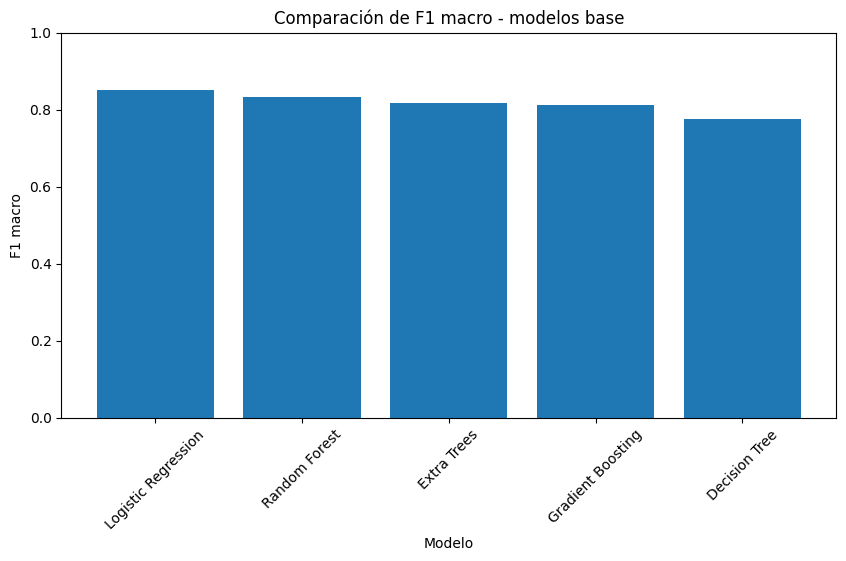

In [13]:
base_results_df = pd.DataFrame([
    {
        "modelo": name,
        "accuracy": data["accuracy"],
        "precision_macro": data["precision_macro"],
        "recall_macro": data["recall_macro"],
        "f1_macro": data["f1_macro"],
        "f1_weighted": data["f1_weighted"],
    }
    for name, data in base_results.items()
]).sort_values(by="f1_macro", ascending=False)

display(base_results_df)

plt.figure(figsize=(10, 5))
plt.bar(base_results_df["modelo"], base_results_df["f1_macro"])
plt.title("Comparación de F1 macro - modelos base")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

## Análisis de la comparación de modelos base

En la comparación de modelos base, el mejor desempeño fue obtenido por `Logistic Regression`, con una accuracy de 0.8500 y un F1 macro de 0.8512. Esto indica que el modelo logró clasificar correctamente el 85% de los registros del conjunto de prueba y mantuvo un desempeño equilibrado entre las tres clases de demanda.

El segundo mejor modelo fue `Random Forest`, con una accuracy de 0.8333 y un F1 macro de 0.8334. Aunque este modelo suele ser más robusto para relaciones no lineales, en este caso fue ligeramente superado por Logistic Regression. Esto sugiere que las nuevas variables agregadas al dataset, como `previous_attendance_rate`, `pre_sale_interest` y `artist_market_score`, ayudan a separar las clases de demanda de forma más clara.

`Extra Trees` y `Gradient Boosting` obtuvieron resultados cercanos, con accuracies de 0.8167 y 0.8125 respectivamente. Por último, `Decision Tree` obtuvo el menor desempeño, con una accuracy de 0.7750, lo cual puede deberse a que un solo árbol de decisión es menos estable que los modelos de ensamble.

En general, los resultados muestran que las variables históricas y de preventa mejoraron la capacidad predictiva del sistema. Además, el uso de métricas como precision, recall y F1 macro permite evaluar el desempeño de forma más completa que usando únicamente accuracy.

## 12. Optimización de modelos

Se optimizan modelos de ensamble con `RandomizedSearchCV`.

La métrica principal para seleccionar el mejor modelo será `f1_macro`, porque permite evaluar el desempeño equilibrado entre las tres clases: baja, media y alta.


In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

models_to_tune = {
    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [8, 10, 12, 16, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None],
        },
    },
    "Extra Trees": {
        "model": ExtraTreesClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [8, 10, 12, 16, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None],
        },
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "params": {
            "model__n_estimators": [100, 150, 200, 300, 400],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
            "model__max_depth": [2, 3, 4, 5],
            "model__subsample": [0.75, 0.85, 1.0],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        },
    },
}

tuned_results = {}

for model_name, config in models_to_tune.items():
    print("\n==============================")
    print(f"Optimizando modelo: {model_name}")
    print("==============================")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", config["model"]),
        ]
    )

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=24,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE,
        error_score="raise",
    )

    search.fit(X_train, y_train)

    best_pipeline_candidate = search.best_estimator_
    metrics = evaluate_model(model_name, best_pipeline_candidate, X_test, y_test)
    metrics["pipeline"] = best_pipeline_candidate
    metrics["best_params"] = search.best_params_
    metrics["best_cv_score_f1_macro"] = search.best_score_

    tuned_results[model_name] = metrics

    print(f"Mejores parámetros: {search.best_params_}")
    print(f"Mejor F1 macro en validación cruzada: {search.best_score_:.4f}")
    print(f"Accuracy en test: {metrics['accuracy']:.4f}")
    print(f"F1 macro en test: {metrics['f1_macro']:.4f}")
    print(f"F1 weighted en test: {metrics['f1_weighted']:.4f}")
    print("\nReporte de clasificación:")
    print(metrics["classification_report"])
    print("Matriz de confusión:")
    print(metrics["confusion_matrix"])


Optimizando modelo: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 10}
Mejor F1 macro en validación cruzada: 0.8332
Accuracy en test: 0.8208
F1 macro en test: 0.8205
F1 weighted en test: 0.8205

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.87      0.85      0.86        80
        baja       0.86      0.89      0.87        80
       media       0.73      0.72      0.73        80

    accuracy                           0.82       240
   macro avg       0.82      0.82      0.82       240
weighted avg       0.82      0.82      0.82       240

Matriz de confusión:
[[68  0 12]
 [ 0 71  9]
 [10 12 58]]

Optimizando modelo: Extra Trees
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'model__n_estimators': 700, 'model_

## 13. Comparación de modelos optimizados

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,cv_f1_macro
2,Gradient Boosting,0.833333,0.837548,0.833333,0.834793,0.834793,0.845849
1,Extra Trees,0.820833,0.825837,0.820833,0.822604,0.822604,0.829960
0,Random Forest,0.820833,0.820465,0.820833,0.820495,0.820495,0.833246


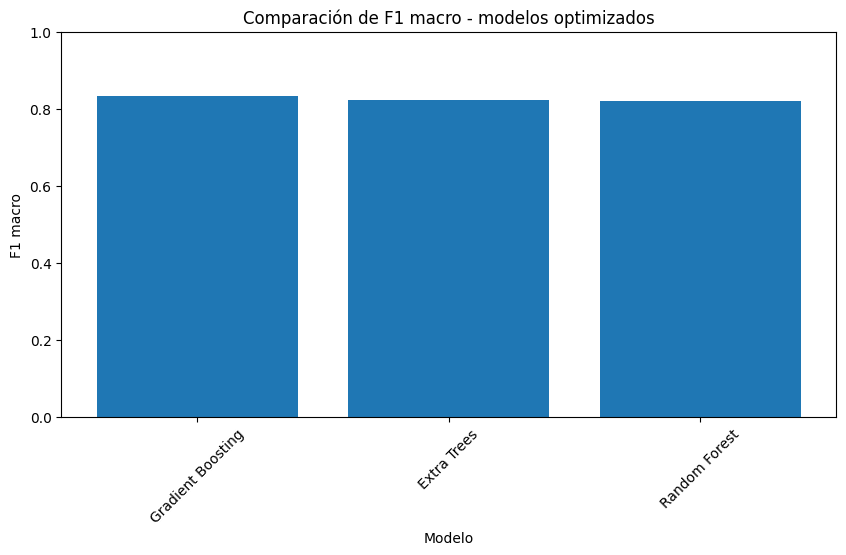

In [15]:
tuned_results_df = pd.DataFrame([
    {
        "modelo": name,
        "accuracy": data["accuracy"],
        "precision_macro": data["precision_macro"],
        "recall_macro": data["recall_macro"],
        "f1_macro": data["f1_macro"],
        "f1_weighted": data["f1_weighted"],
        "cv_f1_macro": data["best_cv_score_f1_macro"],
    }
    for name, data in tuned_results.items()
]).sort_values(by="f1_macro", ascending=False)

display(tuned_results_df)

plt.figure(figsize=(10, 5))
plt.bar(tuned_results_df["modelo"], tuned_results_df["f1_macro"])
plt.title("Comparación de F1 macro - modelos optimizados")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

## 14. Comparación general: modelos base vs optimizados

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,tipo,cv_f1_macro
0,Logistic Regression,0.850000,0.853490,0.850000,0.851166,0.851166,Base,NaN
5,Gradient Boosting,0.833333,0.837548,0.833333,0.834793,0.834793,Optimizado,0.845849
1,Random Forest,0.833333,0.833842,0.833333,0.833382,0.833382,Base,NaN
6,Extra Trees,0.820833,0.825837,0.820833,0.822604,0.822604,Optimizado,0.829960
7,Random Forest,0.820833,0.820465,0.820833,0.820495,0.820495,Optimizado,0.833246
2,Extra Trees,0.816667,0.816667,0.816667,0.816667,0.816667,Base,NaN
3,Gradient Boosting,0.812500,0.813807,0.812500,0.812995,0.812995,Base,NaN
4,Decision Tree,0.775000,0.779755,0.775000,0.776790,0.776790,Base,NaN


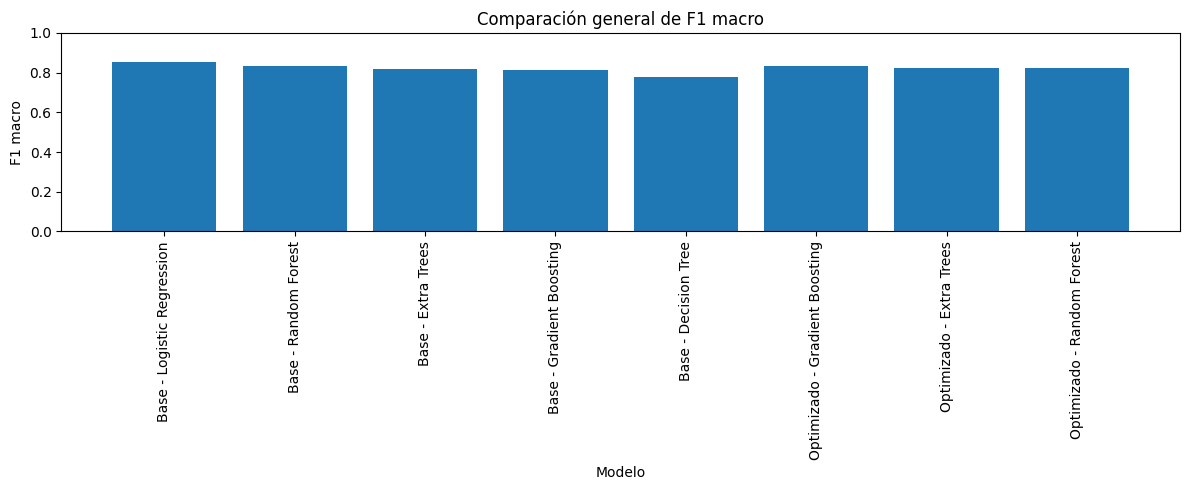

In [16]:
all_results_df = pd.concat([
    base_results_df.assign(tipo="Base"),
    tuned_results_df.assign(tipo="Optimizado"),
], ignore_index=True)

display(all_results_df.sort_values(by="f1_macro", ascending=False))

plt.figure(figsize=(12, 5))
labels = all_results_df["tipo"] + " - " + all_results_df["modelo"]
plt.bar(labels, all_results_df["f1_macro"])
plt.title("Comparación general de F1 macro")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 14.1 Optimización de Logistic Regression

In [26]:
# Se selecciona el mejor modelo usando F1 macro.
# Esta métrica es más equilibrada que accuracy cuando nos importa el desempeño en todas las clases.

combined_results = {}

# Agregar modelos base
for name, data in base_results.items():
    combined_results[f"Base - {name}"] = data

# Agregar modelos optimizados
for name, data in tuned_results.items():
    combined_results[f"Optimizado - {name}"] = data

# Agregar Logistic Regression optimizado
combined_results["Optimizado - Logistic Regression"] = {
    **logistic_metrics,
    "pipeline": logistic_optimized,
    "best_params": logistic_search.best_params_,
    "best_cv_score_f1_macro": logistic_search.best_score_,
}

# Seleccionar mejor modelo final con base en F1 macro
best_model_key = max(
    combined_results,
    key=lambda name: combined_results[name]["f1_macro"]
)

best_result = combined_results[best_model_key]
best_pipeline = best_result["pipeline"]

print("==============================")
print("MEJOR MODELO FINAL")
print("==============================")
print("Modelo:", best_model_key)
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Precision macro: {best_result['precision_macro']:.4f}")
print(f"Recall macro: {best_result['recall_macro']:.4f}")
print(f"F1 macro: {best_result['f1_macro']:.4f}")
print(f"F1 weighted: {best_result['f1_weighted']:.4f}")

if "best_params" in best_result:
    print("\nMejores parámetros:")
    print(best_result["best_params"])

print("\nReporte de clasificación:")
print(best_result["classification_report"])

print("\nMatriz de confusión:")
print(best_result["confusion_matrix"])

MEJOR MODELO FINAL
Modelo: Base - Logistic Regression
Accuracy: 0.8500
Precision macro: 0.8535
Recall macro: 0.8500
F1 macro: 0.8512
F1 weighted: 0.8512

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.92      0.90      0.91        80
        baja       0.88      0.84      0.86        80
       media       0.76      0.81      0.78        80

    accuracy                           0.85       240
   macro avg       0.85      0.85      0.85       240
weighted avg       0.85      0.85      0.85       240


Matriz de confusión:
[[72  0  8]
 [ 0 67 13]
 [ 6  9 65]]


## Análisis del modelo final

El modelo final seleccionado fue `Base - Logistic Regression`, ya que obtuvo el mejor desempeño general entre todos los modelos evaluados. Este modelo alcanzó una accuracy de 0.8500 y un F1 macro de 0.8512, lo que indica un rendimiento equilibrado para clasificar la demanda de conciertos en las categorías `baja`, `media` y `alta`.

En el reporte de clasificación se observa que la clase `alta` obtuvo el mejor desempeño, con un F1-score de 0.91. La clase `baja` también presentó un buen resultado, con un F1-score de 0.86. La clase `media` fue la más difícil de clasificar, con un F1-score de 0.78, lo cual es esperable debido a que representa una categoría intermedia entre baja y alta demanda.

La matriz de confusión muestra que el modelo clasificó correctamente 72 eventos de demanda alta, 67 eventos de demanda baja y 65 eventos de demanda media. Los principales errores ocurren cuando eventos de demanda alta o baja son clasificados como demanda media, y cuando algunos eventos de demanda media se confunden con alta o baja.

En general, el modelo presenta un desempeño aceptable para una primera versión funcional del sistema ConcertDemandAI. Además, al tratarse de Logistic Regression, el modelo tiene ventajas como simplicidad, rapidez de entrenamiento e interpretabilidad.

## 15. Selección del mejor modelo

In [27]:
# Se selecciona el mejor modelo usando F1 macro.
# Esta métrica es más equilibrada que accuracy cuando nos importa el desempeño en todas las clases.

combined_results["Optimizado - Logistic Regression"] = {
    **logistic_metrics,
    "pipeline": logistic_optimized,
    "best_params": logistic_search.best_params_,
    "best_cv_score_f1_macro": logistic_search.best_score_,
}

for name, data in base_results.items():
    combined_results[f"Base - {name}"] = data

for name, data in tuned_results.items():
    combined_results[f"Optimizado - {name}"] = data

best_model_key = max(combined_results, key=lambda name: combined_results[name]["f1_macro"])
best_result = combined_results[best_model_key]
best_pipeline = best_result["pipeline"]

print("==============================")
print("MEJOR MODELO FINAL")
print("==============================")
print("Modelo:", best_model_key)
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Precision macro: {best_result['precision_macro']:.4f}")
print(f"Recall macro: {best_result['recall_macro']:.4f}")
print(f"F1 macro: {best_result['f1_macro']:.4f}")
print(f"F1 weighted: {best_result['f1_weighted']:.4f}")

if "best_params" in best_result:
    print("\nMejores parámetros:")
    print(best_result["best_params"])

print("\nReporte de clasificación:")
print(best_result["classification_report"])

MEJOR MODELO FINAL
Modelo: Base - Logistic Regression
Accuracy: 0.8500
Precision macro: 0.8535
Recall macro: 0.8500
F1 macro: 0.8512
F1 weighted: 0.8512

Reporte de clasificación:
              precision    recall  f1-score   support

        alta       0.92      0.90      0.91        80
        baja       0.88      0.84      0.86        80
       media       0.76      0.81      0.78        80

    accuracy                           0.85       240
   macro avg       0.85      0.85      0.85       240
weighted avg       0.85      0.85      0.85       240



## Comparación de modelos base vs modelos optimizados

Al comparar los modelos base con los modelos optimizados, se observa que la optimización de hiperparámetros no siempre garantiza una mejora en el desempeño. En este caso, el mejor modelo base fue `Logistic Regression`, con una accuracy de 0.8500 y un F1 macro de 0.8512.

Por otro lado, dentro de los modelos optimizados, el mejor resultado fue obtenido por `Gradient Boosting`, con una accuracy de 0.8333 y un F1 macro de 0.8348. Aunque este resultado es competitivo, no supera el desempeño de Logistic Regression.

Esto indica que las variables agregadas al dataset, como `previous_attendance_rate`, `pre_sale_interest` y `artist_market_score`, permiten que un modelo lineal capture de forma adecuada la separación entre las clases de demanda. Por esta razón, no fue necesario seleccionar un modelo más complejo, ya que el modelo simple obtuvo mejor rendimiento.

La comparación también demuestra la importancia de evaluar varios modelos antes de elegir uno final. Aunque Random Forest, Extra Trees y Gradient Boosting suelen ser modelos robustos, en este caso Logistic Regression presentó el mejor equilibrio entre accuracy, precision, recall y F1 macro.

En conclusión, el modelo final seleccionado fue `Logistic Regression`, ya que obtuvo el mejor desempeño general y además ofrece ventajas adicionales como menor complejidad, mayor velocidad de entrenamiento y mejor interpretabilidad.

## 16. Matriz de confusión del mejor modelo

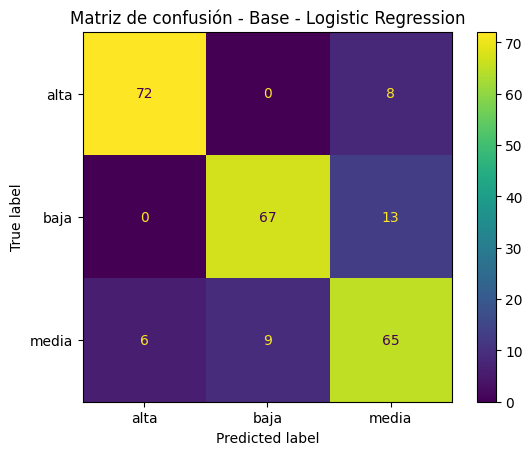

Matriz de confusión:
[[72  0  8]
 [ 0 67 13]
 [ 6  9 65]]


In [18]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test,
)

plt.title(f"Matriz de confusión - {best_model_key}")
plt.show()

print("Matriz de confusión:")
print(best_result["confusion_matrix"])

## Análisis de la matriz de confusión

La matriz de confusión del modelo final muestra un desempeño equilibrado en las tres clases de demanda. Para la clase `alta`, el modelo clasificó correctamente 72 de 80 registros, confundiendo 8 casos como demanda `media`. En la clase `baja`, clasificó correctamente 67 de 80 registros, confundiendo 13 casos como demanda `media`.

La clase `media` fue la más difícil de clasificar, con 65 aciertos de 80 registros. Algunos casos de demanda media fueron confundidos con demanda `alta` y otros con demanda `baja`, lo cual es razonable porque esta categoría representa un punto intermedio entre ambos extremos.

En general, la matriz de confusión confirma que el modelo tiene un buen desempeño para identificar eventos de demanda alta y baja, mientras que la clase media presenta mayor dificultad debido a su naturaleza intermedia.

## 17. Guardado del modelo y métricas

In [19]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, MODEL_PATH)

metrics_to_save = {
    "best_model": best_model_key,
    "accuracy": best_result["accuracy"],
    "precision_macro": best_result["precision_macro"],
    "recall_macro": best_result["recall_macro"],
    "f1_macro": best_result["f1_macro"],
    "f1_weighted": best_result["f1_weighted"],
    "classification_report": best_result["classification_report"],
    "confusion_matrix": best_result["confusion_matrix"].tolist(),
}

if "best_params" in best_result:
    metrics_to_save["best_params"] = best_result["best_params"]

with open(METRICS_JSON_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics_to_save, file, indent=4, ensure_ascii=False)

with open(METRICS_TXT_PATH, "w", encoding="utf-8") as file:
    file.write("Resultados del entrenamiento final\n")
    file.write("=================================\n\n")
    file.write(f"Mejor modelo: {best_model_key}\n")
    file.write(f"Accuracy: {best_result['accuracy']:.4f}\n")
    file.write(f"Precision macro: {best_result['precision_macro']:.4f}\n")
    file.write(f"Recall macro: {best_result['recall_macro']:.4f}\n")
    file.write(f"F1 macro: {best_result['f1_macro']:.4f}\n")
    file.write(f"F1 weighted: {best_result['f1_weighted']:.4f}\n\n")

    if "best_params" in best_result:
        file.write("Mejores parámetros:\n")
        file.write(str(best_result["best_params"]))
        file.write("\n\n")

    file.write("Reporte de clasificación:\n")
    file.write(best_result["classification_report"])
    file.write("\nMatriz de confusión:\n")
    file.write(str(best_result["confusion_matrix"]))

print("Modelo guardado en:", MODEL_PATH)
print("Métricas TXT guardadas en:", METRICS_TXT_PATH)
print("Métricas JSON guardadas en:", METRICS_JSON_PATH)

Modelo guardado en: /content/concert-demand-ml/model/model.pkl
Métricas TXT guardadas en: /content/concert-demand-ml/model/metrics.txt
Métricas JSON guardadas en: /content/concert-demand-ml/model/metrics.json


## 18. Importancia de variables

Si el modelo final tiene atributo `feature_importances_`, se extraen las variables más importantes.

Debido al `OneHotEncoder`, las variables categóricas se expanden en varias columnas.


In [20]:
try:
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    fitted_model = best_pipeline.named_steps["model"]

    cat_names = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names = list(cat_names) + NUMERIC_FEATURES

    importances = fitted_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values(by="importance", ascending=False)

    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(15)
    plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
    plt.title("Top 15 variables más importantes")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.show()

except Exception as error:
    print("No fue posible obtener importancia de variables para este modelo.")
    print("Detalle:", error)

No fue posible obtener importancia de variables para este modelo.
Detalle: 'LogisticRegression' object has no attribute 'feature_importances_'


## 19. Pruebas manuales de predicción

In [29]:
manual_examples = pd.DataFrame([
    {
        "artist": "BTS",
        "genre": "kpop",
        "city": "CDMX",
        "country": "Mexico",
        "venue_type": "stadium",
        "capacity": 55000,
        "month": 9,
        "event_day": "Saturday",
        "days_until_event": 60,
        "marketing_budget": 800000,
        "ticket_price": 2500,
        "artist_popularity": 99,
        "previous_attendance_rate": 0.95,
        "pre_sale_interest": 43000,
        "artist_market_score": 1.00,
        "is_weekend": 1,
        "marketing_per_capacity": 800000 / 55000,
        "price_per_capacity": 2500 / 55000,
        "popularity_marketing": 99 * 800000,
    },
    {
        "artist": "Peso Pluma",
        "genre": "regional_mexicano",
        "city": "Queretaro",
        "country": "Mexico",
        "venue_type": "theater",
        "capacity": 8000,
        "month": 6,
        "event_day": "Wednesday",
        "days_until_event": 120,
        "marketing_budget": 90000,
        "ticket_price": 3500,
        "artist_popularity": 93,
        "previous_attendance_rate": 0.58,
        "pre_sale_interest": 2800,
        "artist_market_score": 0.82,
        "is_weekend": 0,
        "marketing_per_capacity": 90000 / 8000,
        "price_per_capacity": 3500 / 8000,
        "popularity_marketing": 93 * 90000,
    },
    {
        "artist": "The Weeknd",
        "genre": "pop",
        "city": "Guadalajara",
        "country": "Mexico",
        "venue_type": "arena",
        "capacity": 18000,
        "month": 8,
        "event_day": "Friday",
        "days_until_event": 90,
        "marketing_budget": 180000,
        "ticket_price": 1800,
        "artist_popularity": 88,
        "previous_attendance_rate": 0.72,
        "pre_sale_interest": 9500,
        "artist_market_score": 0.92,
        "is_weekend": 1,
        "marketing_per_capacity": 180000 / 18000,
        "price_per_capacity": 1800 / 18000,
        "popularity_marketing": 88 * 180000,
    },
])

display(manual_examples)

manual_predictions = best_pipeline.predict(manual_examples)
manual_probabilities = best_pipeline.predict_proba(manual_examples)

for i, prediction in enumerate(manual_predictions):
    print(f"\nEjemplo: {i + 1}")
    print("Predicción:", prediction)
    print("Probabilidades:")

    for class_name, probability in zip(best_pipeline.classes_, manual_probabilities[i]):
        print(f"{class_name}: {probability:.4f}")

,artist,genre,city,country,venue_type,capacity,month,event_day,days_until_event,marketing_budget,ticket_price,artist_popularity,previous_attendance_rate,pre_sale_interest,artist_market_score,is_weekend,marketing_per_capacity,price_per_capacity,popularity_marketing
0,BTS,kpop,CDMX,Mexico,stadium,55000,9,Saturday,60,800000,2500,99,0.95,43000,1.00,1,14.545455,0.045455,79200000
1,Peso Pluma,regional_mexicano,Queretaro,Mexico,theater,8000,6,Wednesday,120,90000,3500,93,0.58,2800,0.82,0,11.250000,0.437500,8370000
2,The Weeknd,pop,Guadalajara,Mexico,arena,18000,8,Friday,90,180000,1800,88,0.72,9500,0.92,1,10.000000,0.100000,15840000



Ejemplo: 1
Predicción: alta
Probabilidades:
alta: 1.0000
baja: 0.0000
media: 0.0000

Ejemplo: 2
Predicción: baja
Probabilidades:
alta: 0.0000
baja: 0.9996
media: 0.0004

Ejemplo: 3
Predicción: media
Probabilidades:
alta: 0.0014
baja: 0.4470
media: 0.5516


## Conclusión de la prueba manual de predicción

La prueba manual permitió validar el comportamiento del modelo final ante tres escenarios distintos de demanda: alta, baja y media.

En el primer ejemplo, correspondiente a BTS en un estadio de CDMX, el modelo predijo demanda `alta` con una probabilidad de 1.0000. Este resultado es coherente porque el evento tiene alta capacidad, alto presupuesto de marketing, alta popularidad del artista, buen historial de asistencia e interés de preventa elevado.

En el segundo ejemplo, correspondiente a Peso Pluma en un teatro de Querétaro, el modelo predijo demanda `baja` con una probabilidad de 0.9996. Esto se relaciona con un menor tamaño de recinto, menor presupuesto de marketing, menor historial previo de asistencia y un interés de preventa más bajo en comparación con el primer escenario.

En el tercer ejemplo, correspondiente a The Weeknd en una arena de Guadalajara, el modelo predijo demanda `media` con una probabilidad de 0.5516. Este resultado es relevante porque representa un caso intermedio: el artista tiene buena popularidad y el evento se realiza en fin de semana, pero la capacidad, el presupuesto de marketing y el interés de preventa no son tan altos como en el escenario de demanda alta.

También se observa que la predicción de la clase `media` presenta menor seguridad que las clases `alta` y `baja`, ya que la probabilidad de demanda media fue de 0.5516 y la de demanda baja fue de 0.4470. Esto confirma que la clase media es la más difícil de separar, porque comparte características con eventos de baja y alta demanda.

En general, los resultados muestran que el modelo responde de forma lógica ante diferentes combinaciones de variables y puede clasificar escenarios extremos e intermedios. Sin embargo, las probabilidades deben interpretarse con precaución, ya que el dataset utiliza variables simuladas y algunos patrones pueden estar muy marcados.

## 20. Conclusión del entrenamiento

Este notebook permite comparar modelos base y modelos optimizados usando métricas completas.

La selección final se realiza con `f1_macro`, ya que esta métrica evalúa el desempeño promedio entre las clases `baja`, `media` y `alta`. Esto es importante porque no basta con tener buena accuracy general; también se busca que el modelo clasifique razonablemente bien cada nivel de demanda.

El modelo final se guarda en `model/model.pkl` y las métricas en `model/metrics.txt` y `model/metrics.json`.

Este modelo queda listo para integrarse posteriormente en `model/predict.py` y en la aplicación Streamlit de ConcertDemandAI.
